<a href="https://colab.research.google.com/github/zhiyuguo-innis/MSSP607/blob/main/zhiyuguo-innis/MSSP607/Modules/Week_5/Descriptive_Statistics_Student_Performance_Lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descriptive Statistics in Data Analysis and Data Mining
## Student Performance Case Study

### Lesson purpose
Descriptive statistics are the **first analytical layer** between raw data and informed analysis. They help us understand what is typical, how much observations vary, whether unusual values exist, how categories are distributed, and which variables appear to move together. Visualizations complement numerical summaries by revealing shape, clusters, gaps, outliers, and relationships that a table of averages can conceal.

### Learning objectives
By the end of this demonstration, students should be able to:
1. Inspect a dataset for structure, types, missing values, and consistency.
2. Calculate and interpret measures of **center** (mean, median, mode).
3. Calculate and interpret measures of **spread** (range, variance, standard deviation, IQR).
4. Use frequency tables and percentages to summarize categorical variables.
5. Select visualizations appropriate for distributions, comparisons, and relationships.
6. Explain why descriptive analysis should precede predictive modeling or data mining.
7. Distinguish **association** from **causation** when interpreting group differences.

> **Lecture note:** Emphasize that data mining should not begin with a model. A model can be technically correct and still be misleading if the analyst has not first understood the data.

## 1. Load the data and analytical libraries
The notebook expects the CSV file to be in the same folder as the notebook. A fallback path is included for the original ChatGPT workspace.

In [ ]:
from google.colab import userdata
import os

github_token = userdata.get('Neumann')
owner = 'zhiyuguo-innis' # Replace with the GitHub repository owner
repository = 'Demo' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")

Changed directory to: /content/Demo/Demo


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional display settings for classroom readability
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

candidate_files = [
    Path("/content/Demo/WeeklyModules/Week04/StudentPerformanceData.csv"),
    Path("/content/Demo/WeeklyModules/Week04/StudentPerformanceData.csv")
]

for path in candidate_files:
    if path.exists():
        DATA_FILE = path
        break
else:
    raise FileNotFoundError(
        "Place 'Student Performance Data (1).csv' in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE)
print(f"Loaded: {DATA_FILE}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")


Loaded: /content/Demo/WeeklyModules/Week04/StudentPerformanceData.csv
Rows: 1,000 | Columns: 10


In [ ]:
df

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,88,99,95,282,completed,high
996,male,group C,high school,free/reduced,62,55,55,172,none,medium
997,female,group C,high school,free/reduced,59,71,65,195,completed,medium
998,female,group D,some college,standard,68,78,77,223,completed,high


### Why this first step matters
Before calculating statistics, an analyst should know the **unit of observation** and the variables available. Here, each row represents one student record.

> **Lecture note:** Ask students: “What could go wrong if we started averaging columns before checking whether they were numeric, categorical, or identifiers?”

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high


## 2. Data structure and data quality
Descriptive analysis starts with basic data quality checks. We examine data types, missing values, duplicate records, and a logical consistency rule for the total score.

In [ ]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique()
})
quality_summary

,dtype,missing,missing_pct,unique_values
gender,object,0,0.00,2
race/ethnicity,object,0,0.00,5
parental level of education,object,0,0.00,6
lunch,object,0,0.00,2
math score,int64,0,0.00,81
reading score,int64,0,0.00,72
writing score,int64,0,0.00,77
total score,int64,0,0.00,194
test preparation course,object,0,0.00,2
admission prospect,object,0,0.00,3


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

score_columns = ["math score", "reading score", "writing score"]
calculated_total = df[score_columns].sum(axis=1)
consistent_total = (calculated_total == df["total score"])

print(f"Total-score consistency: {consistent_total.mean():.1%} of rows")

Duplicate rows: 0
Total-score consistency: 100.0% of rows


> **Lecture note:** The file contains no missing values, and the total score is internally consistent with the three subject scores. This increases confidence in the descriptive calculations, but it does not prove that the data collection process itself was unbiased or error-free.

## 3. Numerical descriptive statistics
A compact statistical profile gives us a first view of the center and spread of each score variable.

In [ ]:
numeric_cols = ["math score", "reading score", "writing score", "total score"]

basic_summary = df[numeric_cols].describe().T
basic_summary

,count,mean,std,min,25%,50%,75%,max
math score,"1,000.00",66.09,15.16,0.00,57.00,66.00,77.00,100.00
reading score,"1,000.00",69.17,14.60,17.00,59.00,70.00,79.00,100.00
writing score,"1,000.00",68.05,15.20,10.00,57.75,69.00,79.00,100.00
total score,"1,000.00",203.31,42.77,27.00,175.00,205.00,233.00,300.00


### Extend the summary: mean, median, mode, variance, IQR, and skewness
Different statistics answer different questions:
- **Mean:** arithmetic balance point; sensitive to extreme values.
- **Median:** middle observation; more resistant to outliers.
- **Mode:** most frequent value.
- **Standard deviation:** typical distance from the mean.
- **IQR:** spread of the middle 50%; resistant to extreme values.
- **Skewness:** degree of distributional asymmetry.

In [ ]:
def descriptive_profile(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return pd.Series({
        "count": series.count(),
        "mean": series.mean(),
        "median": series.median(),
        "mode": series.mode().iloc[0],
        "min": series.min(),
        "max": series.max(),
        "range": series.max() - series.min(),
        "variance": series.var(),
        "std_dev": series.std(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1,
        "skewness": series.skew()
    })

profile = df[numeric_cols].apply(descriptive_profile).T
profile.round(2)

,count,mean,median,mode,min,max,range,variance,std_dev,Q1,Q3,IQR,skewness
math score,"1,000.00",66.09,66.00,65.00,0.00,100.00,100.00,229.92,15.16,57.00,77.00,20.00,-0.28
reading score,"1,000.00",69.17,70.00,72.00,17.00,100.00,83.00,213.17,14.60,59.00,79.00,20.00,-0.26
writing score,"1,000.00",68.05,69.00,74.00,10.00,100.00,90.00,230.91,15.20,57.75,79.00,21.25,-0.29
total score,"1,000.00",203.31,205.00,204.00,27.00,300.00,273.00,"1,829.44",42.77,175.00,233.00,58.00,-0.30


> **Lecture note:** Compare the math mean (about 66.1) with the median (66). They are close, suggesting the center is not strongly distorted by extreme observations. However, the minimum math score is 0, so the distribution still deserves visual inspection.

> **Teaching point:** A mean without a measure of spread is incomplete. Two classes can have the same mean but very different consistency.

## 4. Visualize score distributions
Histograms answer a question that `describe()` cannot: **What is the shape of the data?**

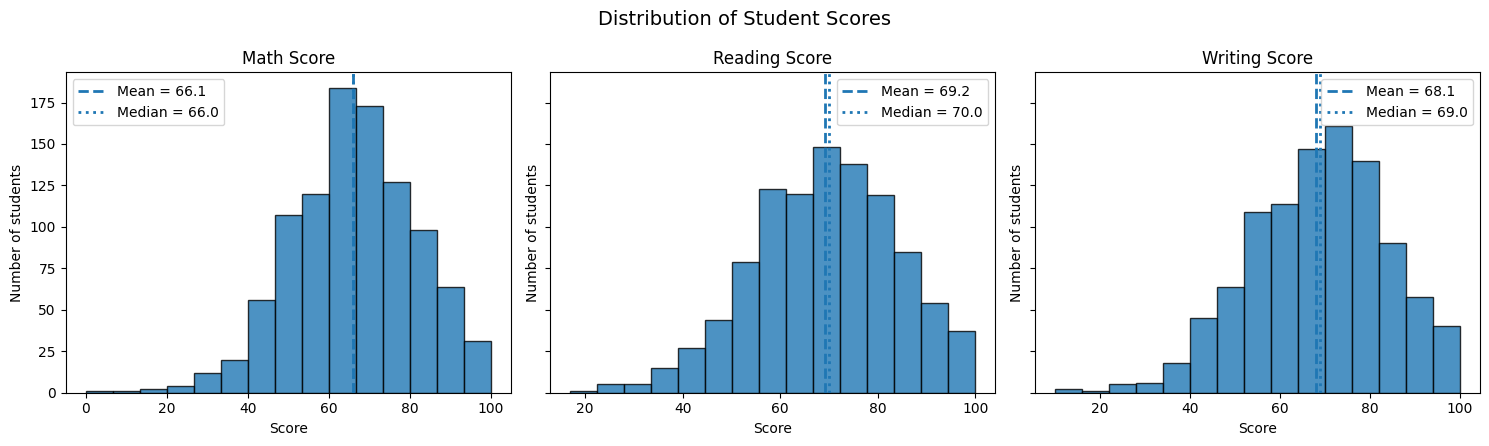

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, col in zip(axes, score_columns):
    ax.hist(df[col], bins=15, edgecolor="black", alpha=0.8)
    ax.axvline(df[col].mean(), linestyle="--", linewidth=2, label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), linestyle=":", linewidth=2, label=f"Median = {df[col].median():.1f}")
    ax.set_title(col.title())
    ax.set_xlabel("Score")
    ax.set_ylabel("Number of students")
    ax.legend()

fig.suptitle("Distribution of Student Scores", fontsize=14)
plt.tight_layout()
plt.show()

> **Lecture note:** Ask students to compare the three distributions. The means and medians are fairly close, and all three score distributions show modest negative skew. The visual makes that shape easier to understand than the skewness coefficient alone.

> **Why visualization matters:** A descriptive statistic compresses information. A graph restores some of the structure that compression removes.

## 5. Outliers and robust statistics
A boxplot summarizes the median, quartiles, spread, and potential outliers. We will also use the common **1.5 × IQR rule** to flag unusually low or high observations.

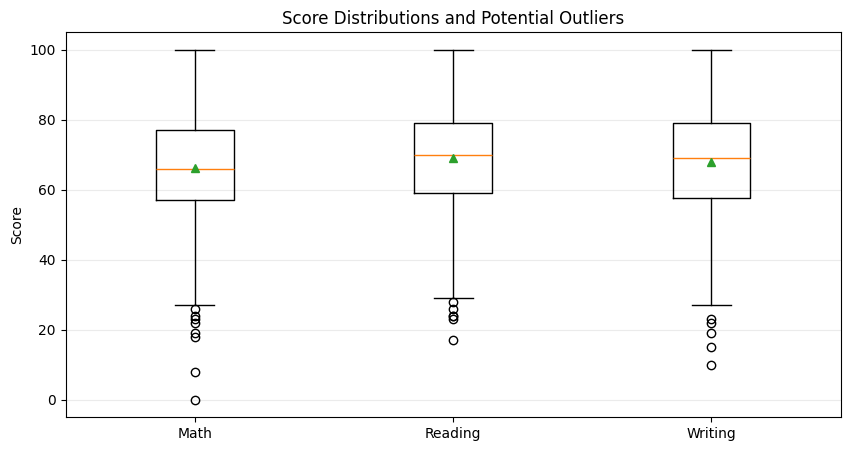

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    [df[c] for c in score_columns],
    tick_labels=["Math", "Reading", "Writing"],
    showmeans=True
)
plt.ylabel("Score")
plt.title("Score Distributions and Potential Outliers")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [ ]:
outlier_rows = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append([col, q1, q3, lower, upper, count])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["variable", "Q1", "Q3", "lower_fence", "upper_fence", "flagged_count"]
)
outlier_summary.round(2)

,variable,Q1,Q3,lower_fence,upper_fence,flagged_count
0,math score,57.00,77.00,27.00,107.00,8
1,reading score,59.00,79.00,29.00,109.00,6
2,writing score,57.75,79.00,25.88,110.88,5
3,total score,175.00,233.00,88.00,320.00,6


> **Lecture note:** “Outlier” does **not** automatically mean “bad data.” A value can be unusual and still be valid. The analyst should investigate before deleting anything. This is one reason exploratory descriptive analysis is essential before model building.

## 6. Categorical descriptive statistics
For categorical variables, the analog of the mean is usually a **frequency distribution**: counts and percentages.

In [ ]:
categorical_cols = [
    "gender", "race/ethnicity", "parental level of education", "lunch",
    "test preparation course", "admission prospect"
]

for col in categorical_cols:
    table = pd.DataFrame({
        "count": df[col].value_counts(),
        "percent": df[col].value_counts(normalize=True).mul(100).round(1)
    })
    print(f"\n{col.upper()}")
    display(table)


GENDER


,count,percent
gender,,
female,518,51.80
male,482,48.20



RACE/ETHNICITY


,count,percent
race/ethnicity,,
group C,319,31.90
group D,262,26.20
group B,190,19.00
group E,140,14.00
group A,89,8.90



PARENTAL LEVEL OF EDUCATION


...

,count,percent
lunch,,
standard,645,64.50
free/reduced,355,35.50



TEST PREPARATION COURSE


,count,percent
test preparation course,,
none,642,64.20
completed,358,35.80



ADMISSION PROSPECT


,count,percent
admission prospect,,
medium,475,47.50
high,356,35.60
low,169,16.90


### Visual example: admission prospect
A bar chart makes category imbalance immediately visible.

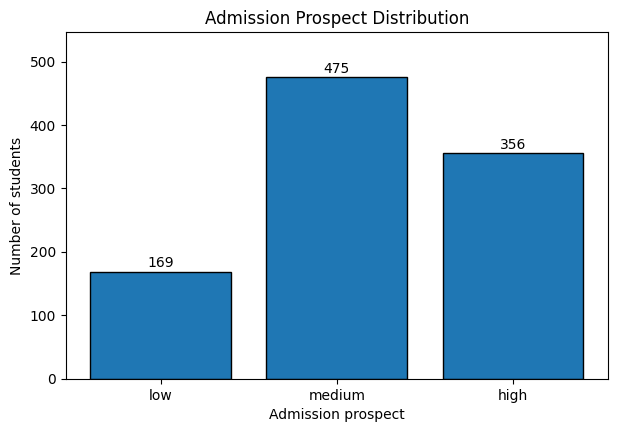

In [ ]:
counts = df["admission prospect"].value_counts().reindex(["low", "medium", "high"])

plt.figure(figsize=(7, 4.5))
bars = plt.bar(counts.index, counts.values, edgecolor="black")
plt.title("Admission Prospect Distribution")
plt.xlabel("Admission prospect")
plt.ylabel("Number of students")

for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 7, f"{value}", ha="center")

plt.ylim(0, counts.max() * 1.15)
plt.show()

> **Lecture note:** The categories are not equally represented: “medium” is the largest group. In data mining, class imbalance can affect classification models and evaluation metrics, so even a basic frequency table can influence later modeling decisions.

## 7. Compare groups with descriptive statistics
Group summaries help reveal patterns that are hidden in an overall average. Here we compare average scores by test-preparation status and lunch category.

**Important:** These are descriptive associations. They do not prove that test preparation or lunch category *caused* the score differences.

In [ ]:
prep_summary = (
    df.groupby("test preparation course")[numeric_cols]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)
prep_summary

math score                    reading score        \
                             count  mean median   std         count  mean   
test preparation course                                                     
completed                      358 69.70  69.00 14.44           358 73.89   
none                           642 64.08  64.00 15.19           642 66.53   

                                     writing score                     \
                        median   std         count  mean median   std   
test preparation course                                                 
completed                75.00 13.64           358 74.42  76.00 13.38   
none                     67.00 14.46           642 64.50  65.00 15.00   

                        total score                      
                              count   mean median   std  
test preparation course                                  
completed                       358 218.01 220.50 39.11  
none                            642 195.12 196.00 42.56

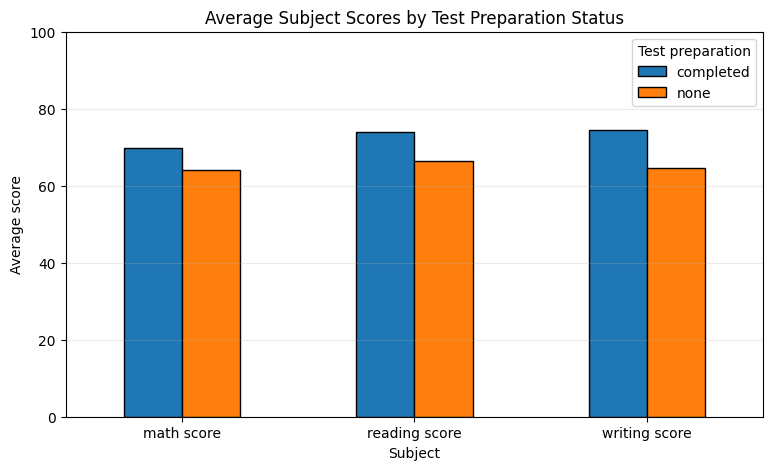

In [ ]:
prep_means = df.groupby("test preparation course")[score_columns].mean().T

prep_means.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.title("Average Subject Scores by Test Preparation Status")
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.xticks(rotation=0)
plt.legend(title="Test preparation")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)
plt.show()

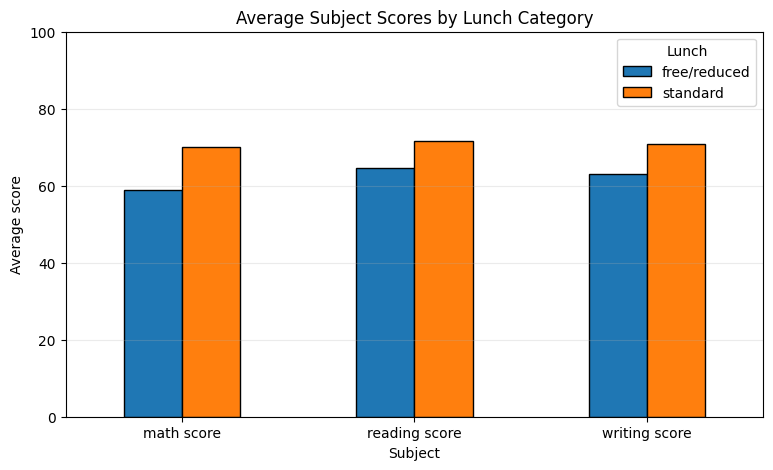

In [ ]:
lunch_means = df.groupby("lunch")[score_columns].mean().T

lunch_means.plot(kind="bar", figsize=(9, 5), edgecolor="black")
plt.title("Average Subject Scores by Lunch Category")
plt.xlabel("Subject")
plt.ylabel("Average score")
plt.xticks(rotation=0)
plt.legend(title="Lunch")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.25)
plt.show()

> **Lecture note:** The group means differ. Use this to explain why descriptive statistics are often the beginning of a question, not the end. The next analytical step might examine possible confounders, sampling design, uncertainty, or a multivariable model.

> **Discussion prompt:** What additional variables would you want before making a causal claim about these group differences?

## 8. Relationships among numeric variables
Correlation summarizes the **direction and strength of a linear relationship** between two numeric variables. A correlation matrix lets us examine several relationships at once.

In [ ]:
corr = df[numeric_cols].corr()
corr.round(3)

,math score,reading score,writing score,total score
math score,1.00,0.82,0.80,0.92
reading score,0.82,1.00,0.95,0.97
writing score,0.80,0.95,1.00,0.97
total score,0.92,0.97,0.97,1.00


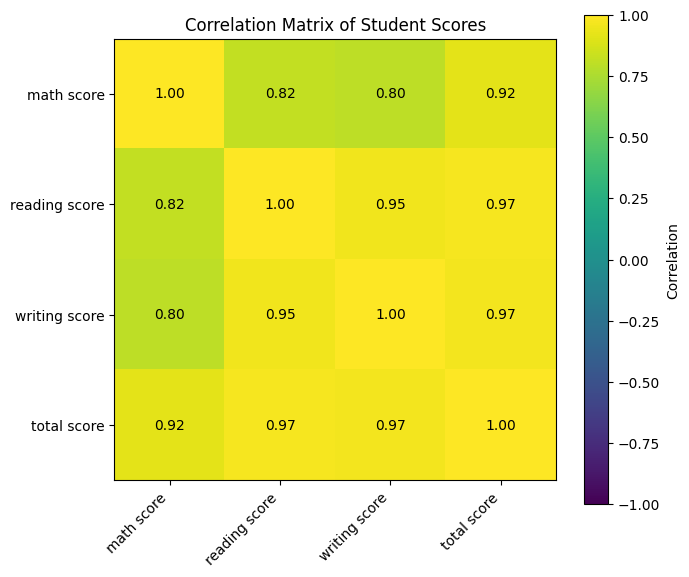

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_cols)), labels=numeric_cols, rotation=45, ha="right")
ax.set_yticks(range(len(numeric_cols)), labels=numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix of Student Scores")
plt.tight_layout()
plt.show()

> **Lecture note:** Reading and writing scores have a very strong positive correlation (about 0.95). Explain that correlation does not tell us why the relationship exists, and it does not prove that improvement in one subject causes improvement in the other.

## 9. Scatterplot: see the relationship behind the correlation
The correlation coefficient is one number. A scatterplot shows whether that number represents a genuine pattern, whether the pattern is linear, and whether there are unusual observations.

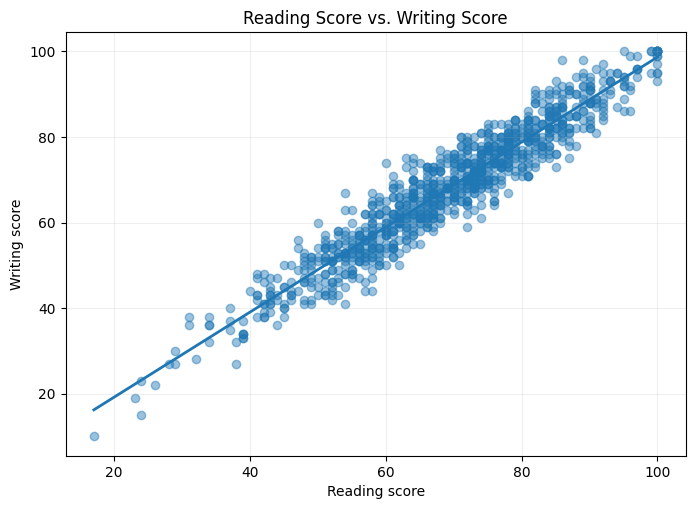

Correlation: 0.955


In [ ]:
x = df["reading score"]
y = df["writing score"]

# Simple best-fit line for visualization
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 5.5))
plt.scatter(x, y, alpha=0.45)
plt.plot(line_x, line_y, linewidth=2)
plt.title("Reading Score vs. Writing Score")
plt.xlabel("Reading score")
plt.ylabel("Writing score")
plt.grid(alpha=0.2)
plt.show()

print(f"Correlation: {x.corr(y):.3f}")

> **Lecture note:** The scatterplot confirms that the strong correlation is not merely an artifact of a few observations. This illustrates a key principle: **pair numerical summaries with graphics whenever possible.**

## 10. Descriptive statistics as preparation for data mining
Descriptive analysis directly supports later modeling decisions:

| Descriptive finding | Why it matters for data mining |
|---|---|
| Missing values | Determines whether imputation or case removal is needed |
| Extreme values | Can distort distance-based models and regression |
| Skewed distributions | May motivate transformation or robust methods |
| Category imbalance | Can distort classification accuracy and training |
| Strong correlations | May indicate redundancy or multicollinearity |
| Different group distributions | May indicate segmentation opportunities or fairness concerns |
| Data-type problems | Can break or mislead modeling pipelines |

> **Lecture note:** Stress that exploratory descriptive analysis is not “just reporting.” It is a diagnostic stage that informs feature engineering, model selection, validation, and interpretation.

## 11. Case-study conclusions
From this dataset we can describe several patterns:

- The dataset contains **1,000 student records** and no missing values.
- Mean and median subject scores are reasonably close, although the distributions contain a small number of unusually low observations.
- Reading and writing scores are strongly positively associated.
- Test-preparation and lunch categories show different average score profiles, but these are **descriptive associations, not causal effects**.
- Admission-prospect categories are imbalanced, which could matter if the variable were used as a classification target.

### Core lesson
Averages alone are not enough. Effective data analysis combines:
1. **Numerical summaries** to quantify center, spread, frequency, and association.
2. **Visualizations** to reveal shape, unusual observations, group patterns, and relationships.
3. **Context and judgment** to avoid mistaking description for explanation or causation.

## 12. Classroom discussion / extension exercises
1. Which statistic—mean or median—would you report if the score distributions were much more skewed? Why?
2. Identify one variable for which a histogram is appropriate and one for which a bar chart is appropriate. Explain the difference.
3. Recreate the group comparison using **medians** instead of means. Does the story change?
4. Create a boxplot of `total score` by `admission prospect`. What pattern do you observe?
5. If `admission prospect` were a machine-learning target, what concern does its frequency distribution raise?
6. Why would it be inappropriate to conclude that completing the test-preparation course *caused* higher scores from this dataset alone?